# VENTAS DE VIDEOJUEGOS REALIZADAS POR ICE EN EL 2016

El objetivo de este proyecto es ayudar a Ice a identificar el comportamiento de los usuarios, definir si el año de lanzamiento incide en las ventas o si hay similitudes o diferencias entre géneros y áreas, determinar las cinco plataformas y los cinco géneros más rentables. 

Para ello se analizará los datos de ventas de videojuegos del año 2016 identificando duplicidad o ausencia de datos para realizar la limpieza de los mismos y posteriormente realizar análisis estadísticos y pruebas de hipótesis. 

## 1. Estudio de datos

### 1.1 Inicialización

In [3]:
# Cargar todas las librerías

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as st

In [4]:
# Cargar el archivo

games = pd.read_csv("games.csv", sep=",")

In [5]:
# Visualización de columnas

print(games.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


In [6]:
# Imprimir la información del archivo

print(games.info())

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB
None


Al imprimir las columnas y la información se identifica lo siguiente:

- Los nombres de las columnas tienen mayúsculas y minúsculas. Es mejor cambiar todo a minúsculas.
- El año es de tipo float y debe ser de tipo int.
- El critic_score tiene tipo float pero se ve que se califica sobre 100 en números enteros por lo que debería ser de tipo int.
- El user_score es de tipo object y debería ser tipo float.
- Existen 2 datos nulos en name y genre.
- Hay varios datos nulos en el año, user_score, critic_score y rating.

## 2. Preparación de datos

### 2.1 Nombres de columnas

In [7]:
# Cambiar nombres de columnas a minúsculas

columns_names = games.columns
new_columns_names = [names.lower() for names in columns_names]
games.columns = new_columns_names

print(games.info())

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  str    
 10  rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB
None


Se cambia el nombre de las columnas todas a minúsculas para mejor visualización y limpieza de datos. 

### 2.2 Valores duplicados

In [8]:
# Revisar filas duplicadas

duplicates = games.duplicated()

print(duplicates.sum())

0


No se encontraron filas duplicadas. 

### 2.3 Valores ausentes

In [9]:
# Comprobar la cantidad de valores ausentes en cada columna

absent = games.isna().sum()

print(absent)

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64


In [10]:
# Comprobar si las filas con nulos en la columna name y en la columna genre son las mismas

absent_name_genre = games[(games['name'].isnull()) & (games['genre'].isnull())]

print(absent_name_genre)

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


In [11]:
# Reemplazar los valores ausentes de las columnas name y genre

games['name'] = games['name'].fillna('undefined')
games['genre'] = games ['genre'].fillna('undefined')

In [12]:
# Reemplazar los valores ausentes de la columna year_of_release

games['year_of_release'] = games['year_of_release'].fillna(np.nan)

In [13]:
# Reemplazar los valores ausentes de las columnas critic_score y user_score

games['critic_score'] = games['critic_score'].fillna(np.nan)
games['user_score'] = games['user_score'].fillna(np.nan)

In [14]:
# Reemplazar los valores ausentes de la columna rating

games['rating'] = games['rating'].fillna('unknown')

Se identificaron 2 valores ausentes en las columnas name y genre. Dado que se trata de pocos registros, es posible que se deba a un error del sistema al no guardar esta información. Sin embargo, estas filas contienen datos completos sobre plataforma, año de lanzamiento y ventas, por lo que se decidió mantenerlas, reemplazando los valores faltantes con 'undefined' para permitir análisis posteriores.

Se encontraron 269 valores ausentes en la columna year_of_release, probablemente debido a un llenado incorrecto de estos campos. Como posteriormente será necesario transformar el tipo de datos de esta columna y realizar análisis relacionados con el año de lanzamiento, se reemplazaron los valores faltantes con NaN. Esto permite trabajar con el resto de la información de las filas sin perder datos relevantes.

Se identificaron 8,578 valores ausentes en la columna critic_score y 6,701 en user_score, lo que probablemente se debe a que estos juegos no fueron calificados. Para facilitar análisis posteriores, los valores numéricos ausentes se reemplazaron con NaN.

Se encontraron 6,766 valores ausentes en la columna rating, posiblemente porque los juegos no recibieron calificación. En este caso, los valores categóricos faltantes se reemplazaron con 'unknown', lo que permite realizar análisis posteriores sin que estos datos interfieran en la interpretación de los resultados.

### 2.3 Tipos de datos

In [15]:
# Verificar nuevamente los tipos de datos de las columnas

print(games.info())

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  float64
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  str    
 10  rating           16715 non-null  str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB
None


In [16]:
# Convertir los datos de la columna 'year_of_release' a int

games['year_of_release'] = games['year_of_release'].astype('Int64')

print(games['year_of_release'].dtype)

Int64


In [17]:
# Revisar por qué la columna user_score se encuentra como tipo object 

print(games['user_score'].unique())

<StringArray>
[  '8',   nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4', '8.2',
   '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2', '8.9', '6.4',
 '7.8', '7.5', '2.6', '7.2', '9.2',   '7', '7.3', '4.3', '7.6', '5.7',   '5',
 '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8', '6.1', '6.7', '5.4',   '4',
 '4.9', '4.5', '9.3', '6.2', '4.2',   '6', '3.7', '4.1', '5.8', '5.6', '5.5',
 '4.4', '4.6', '5.9', '3.9', '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5',
 '2.5', '1.9',   '3', '2.7', '2.2',   '2', '9.5', '2.1', '3.6', '2.8', '1.8',
 '3.8',   '0', '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
 '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9',   '1', '9.7']
Length: 97, dtype: str


In [18]:
#  Convertir 'tbd' en user_score a NaN

games['user_score'] = games['user_score'].replace('tbd', np.nan)

In [19]:
#  Convertir el tipo de dato de la columna user_score de object a Int64

games['user_score'] = games['user_score'].astype('float64')

print(games['user_score'].dtype)

float64


In [20]:
# Verificar los cambios aplicados a los tipos de datos de las columnas

print(games.info())

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  str    
dtypes: Int64(1), float64(6), str(4)
memory usage: 1.4 MB
None


Se cambió el tipo de datos de la columna year_of_release de float64 a Int64 debido a que los años son números enteros. 

La columna user_score se encuentra definida como tipo object, aunque representa calificaciones numéricas. Por este motivo, se revisaron los datos de la columna para identificar la causa de esta inconsistencia.

Se detectó la presencia de valores como 'tbd' (to be defined), los cuales indican que la calificación aún no ha sido asignada.

En consecuencia, se decidió convertir los valores 'tbd' a NaN, con el fin de estandarizar la representación de datos faltantes y habilitar el tratamiento de la columna como valores numéricos en futuros análisis.

### Ventas totales

In [21]:
# Calcular las ventas totales en la nueva columna 'total_sales'

games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

print(games.info())
print(games.head())

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  str    
 11  total_sales      16715 non-null  float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 1.5 MB
None
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      

Para cálculos posteriores se coloca una nueva columna denominada 'total_sales' que representa la suma de las ventas en todas las regiones para cada juego. 

## 3. Análisis de datos

### 3.1 Juegos por año de lanzamiento

In [22]:
# Calcular los juegos lanzados en cada año de lanzamiento

games_per_year = games.groupby(['year_of_release'])['name'].count()

print(games_per_year)

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


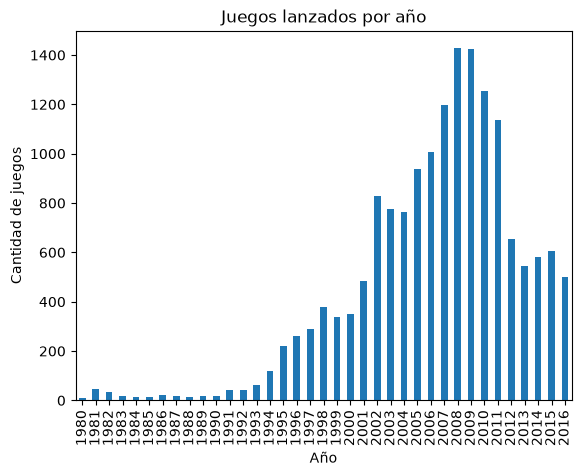

In [23]:
# Gráfico de barras sobre los juegos lanzados por año

games_per_year.plot(kind = 'bar', title = 'Juegos lanzados por año', xlabel = 'Año', ylabel='Cantidad de juegos' )

plt.show()

Se calcula la cantidad de juegos lanzados por año y para poder interpretar la información y su relevancia por periodo se elabora un gráfico de barras. En él se identifica que la cantidad de juegos lanzados en años anteriores a 1995 es menos de 200 por año, y los lanzamientos se concentran en juegos a partir de esos años, siendo mayores los del 2008 y 2009. Por tanto, los juegos con año de lanzamiento anterior a 1995 no se consideran significativos. 

### 3.2 Ventas por plataforma

In [24]:
# Calcular el total de ventas por plataforma

sales_per_platform = games.groupby('platform')['total_sales'].sum()
sales_per_platform = sales_per_platform.sort_values(ascending=False)

print(sales_per_platform)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


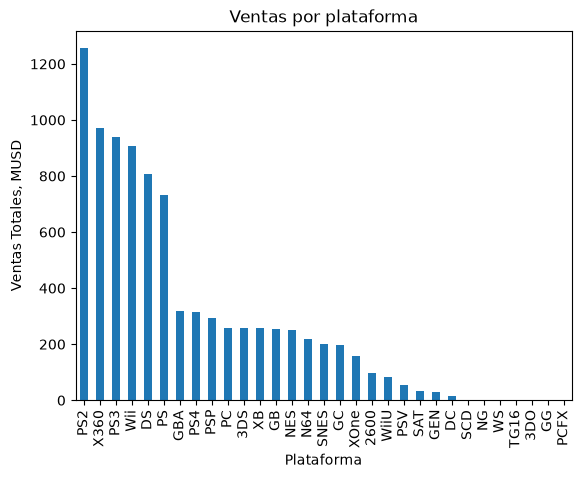

In [25]:
# Graficar la distribución de ventas por plataforma

sales_per_platform.plot(kind='bar',title='Ventas por plataforma',xlabel='Plataforma',ylabel='Ventas Totales, MUSD')

plt.show()

In [26]:
# Lista de plataformas principales
platforms_list = ['PS2', 'X360', 'Wii', 'PS3', 'DS', 'PS']

# Filtrar filas que tengan esas plataformas
top_platforms = games[games['platform'].isin(platforms_list)]

print(top_platforms.head())
print(top_platforms.info())

                    name platform  year_of_release     genre  na_sales  \
0             Wii Sports      Wii             2006    Sports     41.36   
2         Mario Kart Wii      Wii             2008    Racing     15.68   
3      Wii Sports Resort      Wii             2009    Sports     15.61   
6  New Super Mario Bros.       DS             2006  Platform     11.28   
7               Wii Play      Wii             2006      Misc     13.96   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         2.95          80.0         8.0      E   
6      9.14      6.50         2.88          89.0         8.5      E   
7      9.18      2.93         2.84          58.0         6.6      E   

   total_sales  
0        82.54  
2        35.52  
3        32.77  
6        29.80  
7        28.91  
<class 'pandas.DataFrame'>

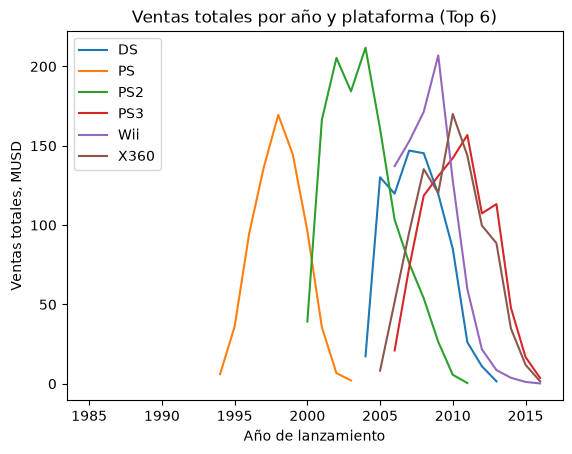

In [27]:
# Distribución basada en los datos de cada año

top_platforms_by_year = (top_platforms.groupby(['platform','year_of_release'])['total_sales'].sum().unstack('platform'))

top_platforms_by_year.plot(kind='line', title='Ventas totales por año y plataforma (Top 6)', xlabel='Año de lanzamiento', ylabel='Ventas totales, MUSD')

plt.legend()
plt.show()

Al calcular las ventas totales por plataforma, el gráfico evidencia una separación marcada: seis plataformas presentan ventas significativamente superiores al resto, todas por encima de los 600 millones de dólares.

Se seleccionan estas plataformas principales, cuyas ventas superan dicho umbral, para continuar con un análisis de la distribución de ventas a lo largo de los años.

Al analizar la distribución temporal de las ventas, se observa que cada plataforma presenta un punto claro de inicio y un cierre definitivo en su ciclo de ventas. Por ejemplo, la plataforma PS surge alrededor de 1994, alcanza su mayor volumen de ventas en 1998 y deja de comercializarse aproximadamente en 2004.

En el caso de PS y Wii, se identifica un único pico máximo de ventas, mientras que el resto de las plataformas principales muestran dos picos relevantes que sostienen un nivel elevado de ventas durante más tiempo. En general, las plataformas mantienen ventas superiores a los 100 millones de dólares durante un período de 4 a 6 años y presentan un ciclo de vida cercano a los 10 años.

Plataformas como DS, PS y PS2 fueron populares en su momento, pero actualmente ya no registran ventas. Además, se observa que las plataformas más recientes aparecen con una diferencia aproximada de un año entre lanzamientos, mientras que las más antiguas tenían intervalos mayores; por ejemplo, entre el lanzamiento de PS y PS2 transcurrieron cerca de 5 años.

### 3.3 Datos base

In [28]:
# Filtrar los datos del periodo relevante

period = [2012, 2013, 2014, 2015, 2016]
period_data = games[games['year_of_release'].isin(period)].copy()

print(period_data.info())
print(period_data.head())

<class 'pandas.DataFrame'>
Index: 2886 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2886 non-null   str    
 1   platform         2886 non-null   str    
 2   year_of_release  2886 non-null   Int64  
 3   genre            2886 non-null   str    
 4   na_sales         2886 non-null   float64
 5   eu_sales         2886 non-null   float64
 6   jp_sales         2886 non-null   float64
 7   other_sales      2886 non-null   float64
 8   critic_score     1312 non-null   float64
 9   user_score       1531 non-null   float64
 10  rating           2886 non-null   str    
 11  total_sales      2886 non-null   float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 295.9 KB
None
                          name platform  year_of_release         genre  \
16          Grand Theft Auto V      PS3             2013        Action   
23          Grand Theft Auto V     X360           

Se escoge un periodo de 5 años previos a 2016 para que formen parte del análisis que ayudará a realizar predicción del año 2017 debido a que se considera un periodo suficiente para recabar la información que muestre el comportamiento reciente de las plataforma, por tanto el periodo comprende los años 2012 al 2016 y arroja un total de 2886 filas. 



### 3.4 Plataformas rentables

In [29]:
# Calcular el total de ventas por plataforma para el periodo relevante

sales_period = period_data.groupby('platform')['total_sales'].sum()
sales_period = sales_period.sort_values(ascending=False)

print(sales_period)

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64


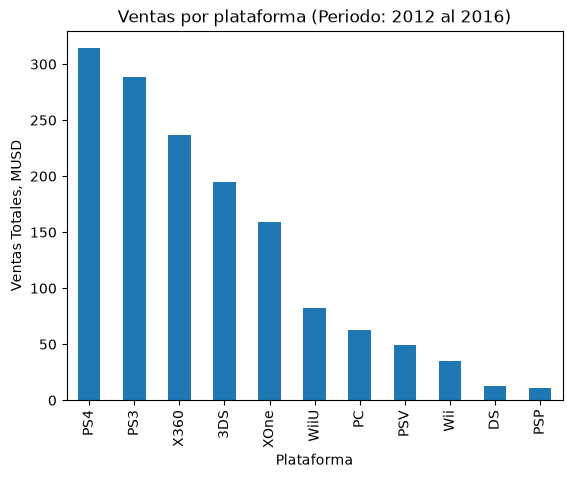

In [30]:
# Graficar la distribución de ventas por plataforma en el periodo relevante

sales_period.plot(kind='bar',title='Ventas por plataforma (Periodo: 2012 al 2016)',xlabel='Plataforma',ylabel='Ventas Totales, MUSD')

plt.show()

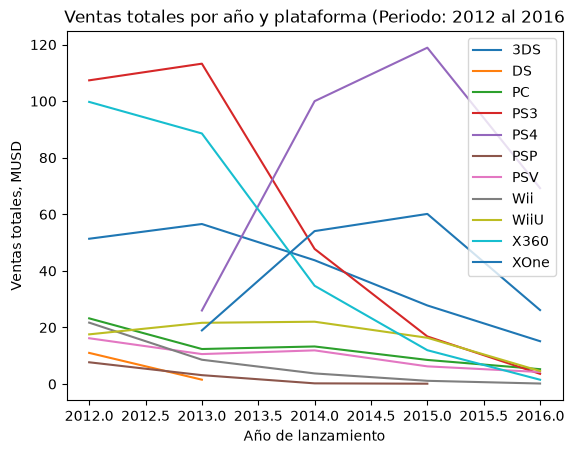

In [31]:
# Distribución basada en los datos de cada año del periodo relevante

top_platforms_period = (period_data.groupby(['platform','year_of_release'])['total_sales'].sum().unstack('platform'))

top_platforms_period.plot(kind='line', title='Ventas totales por año y plataforma (Periodo: 2012 al 2016', xlabel='Año de lanzamiento', ylabel='Ventas totales, MUSD')

plt.legend()
plt.show()

Dentro del periodo escogido se suman las ventas por plataformas y se determina que las líderes en ventas son: PS4, PS3, X360, 3DS y XOne ya que cuentan con más de 150 millones cada una, siendo este un número importante. 

Mediante un gráfico de líneas para evidenciar las ventas por año de las plataformas dentro del periodo relevante se determina que las plataformas que al momento mantienen ventas altas y que su año de lanzamiento fue el más reciente hasta el momento, es decir el 2013, coresponden a PS4 y XOne.

Todas las plataformas registran tendencia a reducir ventas, inclusive, algunas como DS y PSP ya salieron del mercado. Sin embargo, PS4 y XOne son las que comenzaron esta tendencia a la baja de manera más reciente y que no es tan sostenido.

De manera adicional se considera que aproximadamente el máximo de ventas se da en 4 años y el ciclo de vida es de 10 años en promedio las plataformas que tienen 3 años aún pueden tener ventas importantes.

Por estas razones es que se estima que las plataformas más rentables en el año 2017 sean PS4 y XOne.

### 3.4 Ventas globales

In [32]:
# Filtrar la información de las plataformas líder en ventas en el periodo relevante

list_relevant_platforms = ['PS4', 'PS3', 'X360', '3DS', 'XOne']
relevant_platforms = period_data[period_data['platform'].isin(list_relevant_platforms)].copy()
   
print(relevant_platforms.info())
print(relevant_platforms.head())

<class 'pandas.DataFrame'>
Index: 1820 entries, 16 to 16710
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1820 non-null   str    
 1   platform         1820 non-null   str    
 2   year_of_release  1820 non-null   Int64  
 3   genre            1820 non-null   str    
 4   na_sales         1820 non-null   float64
 5   eu_sales         1820 non-null   float64
 6   jp_sales         1820 non-null   float64
 7   other_sales      1820 non-null   float64
 8   critic_score     910 non-null    float64
 9   user_score       1071 non-null   float64
 10  rating           1820 non-null   str    
 11  total_sales      1820 non-null   float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 186.6 KB
None
                          name platform  year_of_release         genre  \
16          Grand Theft Auto V      PS3             2013        Action   
23          Grand Theft Auto V     X360           

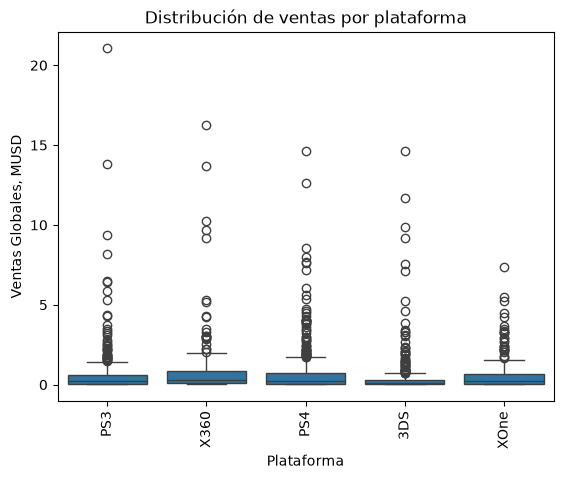

In [33]:
# Diagrama de caja para las ventas globales por plataforma

sns.boxplot(data=relevant_platforms, 
            x='platform', 
            y='total_sales')

plt.title('Distribución de ventas por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales, MUSD')
plt.xticks(rotation=90)
plt.show()

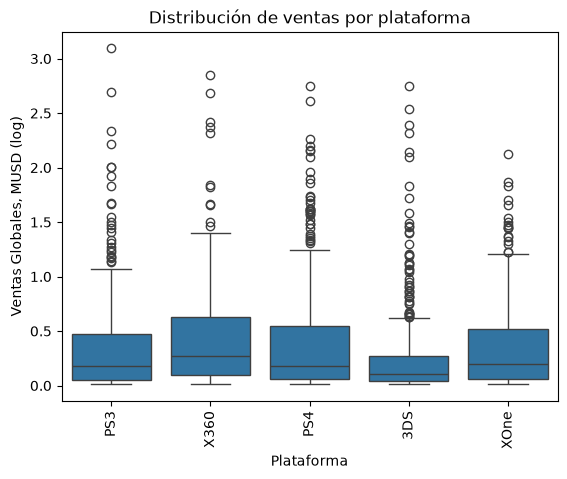

In [34]:
# Aplicar logaritmo a los datos de ventas

relevant_platforms['sales_log'] = np.log1p(relevant_platforms['total_sales'])

# Diagrama de caja para las ventas globales por plataforma (con logaritmo)

sns.boxplot(data=relevant_platforms, 
            x='platform', 
            y='sales_log')

plt.title('Distribución de ventas por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales, MUSD (log)')
plt.xticks(rotation=90)
plt.show()

In [35]:
# Cálculo de media de ventas en las plataformas relevantes en el periodo escogido

stats_platforms = relevant_platforms.groupby('platform')['total_sales'].agg(['mean','median']).sort_values(by='mean', ascending=False)

print(stats_platforms)

              mean  median
platform                  
X360      0.810068    0.31
PS4       0.801378    0.20
XOne      0.645020    0.22
PS3       0.585781    0.20
3DS       0.491439    0.11


Para el análisis con diagramas de caja se seleccionaron las plataformas identificadas previamente como líderes en ventas dentro del periodo relevante. Estas plataformas representan aquellas que se estiman más rentables hacia 2017.

Para mejorar la visualización en el gráfico de caja se creó una nueva columna aplicando logaritmos a los datos de ventas, lo que permite reducir la influencia de valores extremos y observar mejor la distribución.

El gráfico evidencia que las plataformas presentan un comportamiento similar: todas muestran varios outliers que se alejan significativamente del valor típico de ventas, representado por la mediana.

Si bien las diferencias en la mediana y en los cuartiles no son muy marcadas, sí existen variaciones puntuales entre plataformas. En general, las cinco analizadas muestran que la mayoría de los juegos registran ventas por debajo de un millón de dólares, con medianas inferiores a 0.3 millones de dólares. Sin embargo, todas presentan una alta dispersión hacia arriba, con títulos que alcanzan ventas muy elevadas.

En cuanto a las diferencias específicas, se observa que 3DS tiene ventas menores en comparación con las demás plataformas en el periodo analizado. Por otro lado, PS3 y X360 concentran más juegos con ventas altas que 3DS o XOne, lo que se refleja en la mayor cantidad de puntos que se extienden hacia arriba en el gráfico.

Finalmente, en todas las plataformas el promedio de ventas se ubica muy por encima de la mediana. Esto se debe a la alta dispersión y a la presencia de títulos con ventas extraordinarias, que elevan la media y generan una diferencia notable respecto al valor típico de la mayoría de los juegos.

### 3.5 Reseñas de usuarios y profesionales

In [36]:
# Filtrar datos de la plataforma PS4

data_PS4_period = period_data[period_data['platform'].isin(['PS4'])].copy()

print(data_PS4_period.head())
print(data_PS4_period.info())

                              name platform  year_of_release    genre  \
31       Call of Duty: Black Ops 3      PS4             2015  Shooter   
42              Grand Theft Auto V      PS4             2014   Action   
77                         FIFA 16      PS4             2015   Sports   
87    Star Wars Battlefront (2015)      PS4             2015  Shooter   
92  Call of Duty: Advanced Warfare      PS4             2014  Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
31      6.03      5.86      0.36         2.38           NaN         NaN   
42      3.96      6.31      0.38         1.97          97.0         8.3   
77      1.12      6.12      0.06         1.28          82.0         4.3   
87      2.99      3.49      0.22         1.28           NaN         NaN   
92      2.81      3.48      0.14         1.23          83.0         5.7   

     rating  total_sales  
31  unknown        14.63  
42        M        12.62  
77        E         8.58  
87

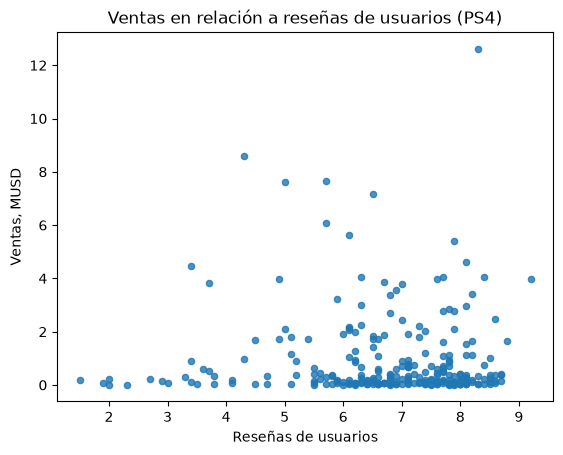

In [37]:
# Gráfico de dispersión cómo las reseñas de usuarios afectan las ventas en la plataforma PS4

data_PS4_period.plot(x='user_score', y='total_sales', kind='scatter', title='Ventas en relación a reseñas de usuarios (PS4)', alpha=0.8, xlabel='Reseñas de usuarios', ylabel='Ventas, MUSD')

plt.show()

In [38]:
# Correlación cómo las reseñas de usuarios afectan las ventas en la plataforma PS4

correlacion_sales_user_PS4 = data_PS4_period['total_sales'].corr(data_PS4_period['user_score'])

print('La correlación entre las ventas y las reseñas de usuarios en PS4 es:', correlacion_sales_user_PS4)

La correlación entre las ventas y las reseñas de usuarios en PS4 es: -0.031957110204556376


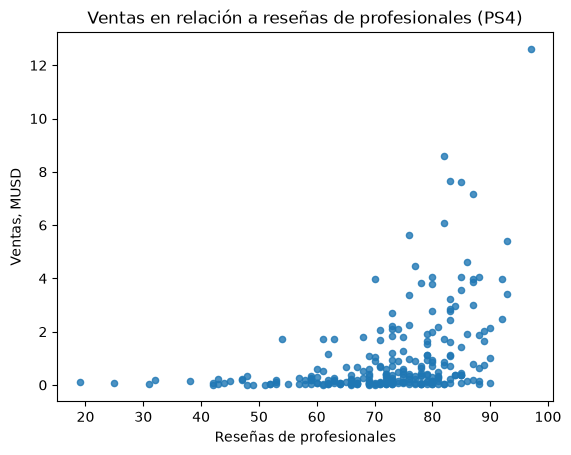

In [39]:
# Gráfico de dispersión cómo las reseñas de profesionales afectan las ventas en la plataforma PS4

data_PS4_period.plot(x='critic_score', y='total_sales', kind='scatter', title='Ventas en relación a reseñas de profesionales (PS4)', alpha=0.8, xlabel='Reseñas de profesionales', ylabel='Ventas, MUSD')

plt.show()

In [40]:
# Correlación cómo las reseñas de profesionales afectan las ventas en la plataforma PS4

correlacion_sales_critic_PS4 = data_PS4_period['total_sales'].corr(data_PS4_period['critic_score'])

print('La correlación entre las ventas y las reseñas de profesionales en PS4 es:', correlacion_sales_critic_PS4)

La correlación entre las ventas y las reseñas de profesionales en PS4 es: 0.406567902061781


Se analiza la relación entre las ventas y las reseñas de usuarios y profesionales para la plataforma PS4, seleccionada por ser una de las de mayor volumen de ventas en el periodo relevante.

En el caso de las reseñas de usuarios, el gráfico de dispersión no muestra una tendencia definida y la correlación obtenida es de -0.03, lo que indica que no existe una relación lineal significativa entre las calificaciones de los jugadores y las ventas. En otras palabras, las opiniones de los usuarios no parecen influir directamente en la venta de los juegos.

Por otro lado, las reseñas de profesionales muestran una ligera tendencia positiva en el gráfico de dispersión, confirmada por una correlación de 0.4. Esto sugiere que, aunque el efecto no es muy fuerte, existe cierta relación: a medida que las calificaciones de los críticos aumentan, las ventas tienden a ser mayores.

### 3.6 Ventas en otras plataformas

In [41]:
# Filtrar datos de la plataforma XOne

data_XOne_period = period_data[period_data['platform'].isin(['XOne'])].copy()

# Imprimir nueva información

print(data_XOne_period.head())
print(data_XOne_period.info())

                               name platform  year_of_release         genre  \
99        Call of Duty: Black Ops 3     XOne             2015       Shooter   
165              Grand Theft Auto V     XOne             2014        Action   
179  Call of Duty: Advanced Warfare     XOne             2014       Shooter   
242               Halo 5: Guardians     XOne             2015       Shooter   
270                       Fallout 4     XOne             2015  Role-Playing   

     na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
99       4.59      2.11      0.01         0.68           NaN         NaN   
165      2.81      2.19      0.00         0.47          97.0         7.9   
179      3.22      1.55      0.01         0.48          81.0         5.4   
242      2.78      1.27      0.03         0.41          84.0         6.4   
270      2.51      1.32      0.01         0.38          88.0         6.2   

      rating  total_sales  
99   unknown         7.39  
165        M

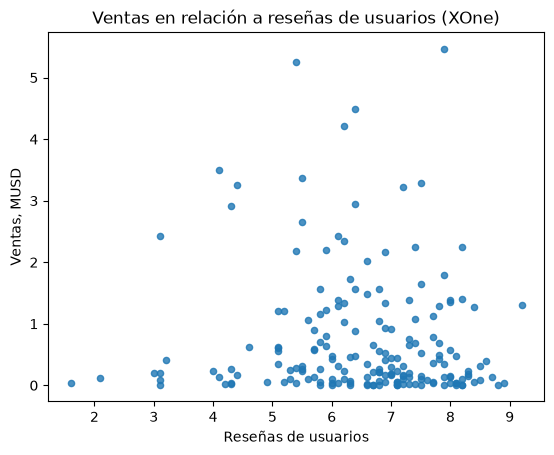

In [42]:
# Gráfico de dispersión cómo las reseñas de usuarios afectan las ventas en la plataforma XOne

data_XOne_period.plot(x='user_score', y='total_sales', kind='scatter', title='Ventas en relación a reseñas de usuarios (XOne)', alpha=0.8, xlabel='Reseñas de usuarios', ylabel='Ventas, MUSD')

plt.show()

In [43]:
# Correlación cómo las reseñas de usuarios afectan las ventas en la plataforma XOne

correlacion_sales_user_XOne = data_XOne_period['total_sales'].corr(data_XOne_period['user_score'])

print('La correlación entre las ventas y las reseñas de profesionales es:', correlacion_sales_user_XOne)

La correlación entre las ventas y las reseñas de profesionales es: -0.06892505328279412


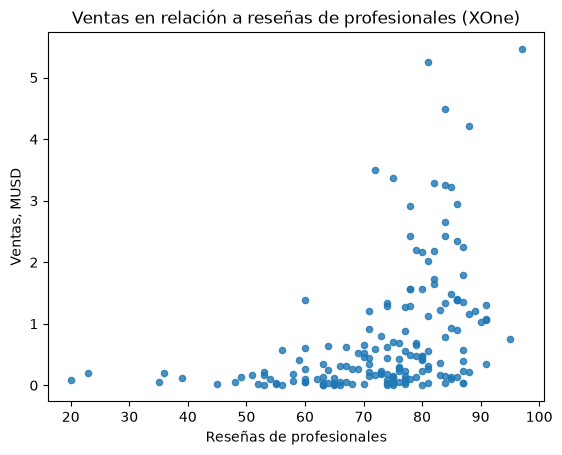

In [44]:
# Gráfico de dispersión cómo las reseñas de profesionales afectan las ventas en la plataforma XOne

data_XOne_period.plot(x='critic_score', y='total_sales', kind='scatter', title='Ventas en relación a reseñas de profesionales (XOne)', alpha=0.8, xlabel='Reseñas de profesionales', ylabel='Ventas, MUSD')

plt.show()

In [45]:
# Correlación cómo las reseñas de profesionales afectan las ventas en la plataforma XOne

correlacion_sales_critic_XOne= data_XOne_period['total_sales'].corr(data_XOne_period['critic_score'])

print('La correlación entre las ventas y las reseñas de profesionales en XOne es:', correlacion_sales_critic_XOne)

La correlación entre las ventas y las reseñas de profesionales en XOne es: 0.41699832800840175


Se analiza también la relación entre las ventas y las reseñas de usuarios y profesionales para la plataforma XOne, que también es una de las de mayor volumen de ventas en el periodo relevante y los resultados son muy cercanos al análisis realizado para la plataforma PS4. 

En el caso de las reseñas de usuarios, el gráfico de dispersión no muestra una tendencia definida y la correlación obtenida es de -0.06, un valor muy cercano a 0, lo que indica que no existe una relación lineal significativa entre las calificaciones de los jugadores y las ventas en esta plataforma, al igual que en la plataforma PS4. 

Por otro lado, las reseñas de profesionales muestran una ligera tendencia positiva en el gráfico de dispersión, confirmada por una correlación de 0.41. Esto sugiere que, aunque el efecto no es muy fuerte, existe cierta relación: a medida que las calificaciones de los críticos aumentan, las ventas tienden a ser mayores.

In [46]:
# Filtrar datos de la plataforma PS3

data_PS3_period = period_data[period_data['platform'].isin(['PS3'])].copy()

print(data_PS3_period.head())
print(data_PS3_period.info())

                           name platform  year_of_release    genre  na_sales  \
16           Grand Theft Auto V      PS3             2013   Action      7.02   
34   Call of Duty: Black Ops II      PS3             2012  Shooter      4.99   
69         Call of Duty: Ghosts      PS3             2013  Shooter      4.10   
81               FIFA Soccer 13      PS3             2012   Action      1.06   
126                     FIFA 14      PS3             2013   Sports      0.78   

     eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
16       9.09      0.98         3.96          97.0         8.2      M   
34       5.73      0.65         2.42          83.0         5.3      M   
69       3.63      0.38         1.25          71.0         2.6      M   
81       5.01      0.13         1.97          88.0         6.6      E   
126      4.24      0.07         1.37          86.0         4.3      E   

     total_sales  
16         21.05  
34         13.79  
69          9.36  
81  

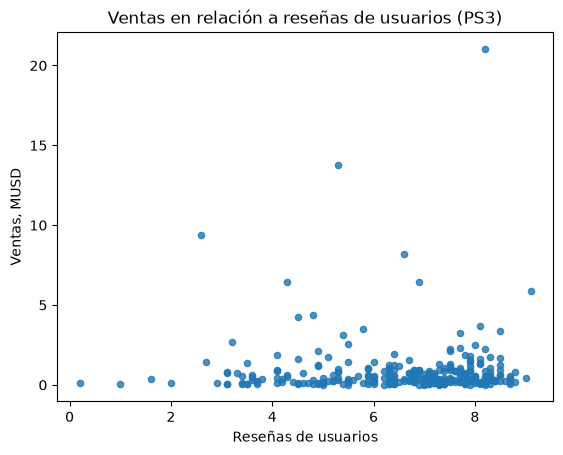

In [47]:
# Gráfico de dispersión cómo las reseñas de usuarios afectan las ventas en la plataforma PS3

data_PS3_period.plot(x='user_score', y='total_sales', kind='scatter', title='Ventas en relación a reseñas de usuarios (PS3)', alpha=0.8, xlabel='Reseñas de usuarios', ylabel='Ventas, MUSD')

plt.show()

In [48]:
# Correlación cómo las reseñas de usuarios afectan las ventas en la plataforma PS3

correlacion_sales_user_PS3 = data_PS3_period['total_sales'].corr(data_PS3_period['user_score'])

print('La correlación entre las ventas y las reseñas de usuarios en PS3 es:', correlacion_sales_user_PS3)

La correlación entre las ventas y las reseñas de usuarios en PS3 es: -0.005143522887113828


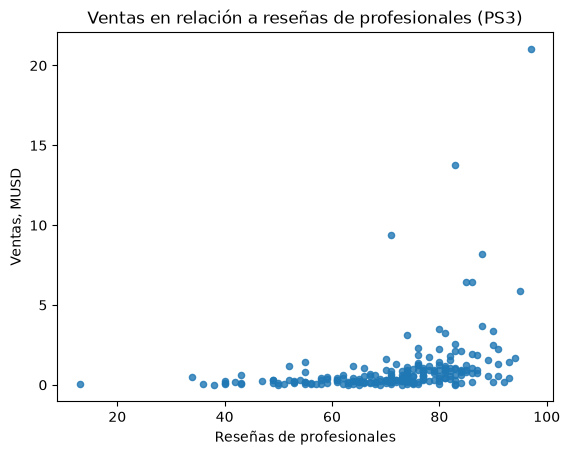

In [49]:
# Gráfico de dispersión cómo las reseñas de profesionales afectan las ventas en la plataforma PS3

data_PS3_period.plot(x='critic_score', y='total_sales', kind='scatter', title='Ventas en relación a reseñas de profesionales (PS3)', alpha=0.8, xlabel='Reseñas de profesionales', ylabel='Ventas, MUSD')

plt.show()

In [50]:
# Correlación cómo las reseñas de profesionales afectan las ventas en la plataforma PS3

correlacion_sales_critic_PS3= data_PS3_period['total_sales'].corr(data_PS3_period['critic_score'])

print('La correlación entre las ventas y las reseñas de profesionales en PS3 es:', correlacion_sales_critic_PS3)

La correlación entre las ventas y las reseñas de profesionales en PS3 es: 0.3314972592629587


Finalmente se analiza también la relación entre las ventas y las reseñas de usuarios y profesionales para la plataforma PS3, que también es una de las de mayor volumen de ventas en el periodo relevante y se observa el mismo comportamiento que en los análisis realizados para las plataformas PS4 y XOne.

En el caso de las reseñas de usuarios para la plataforma PS3, el gráfico de dispersión no muestra una tendencia definida y la correlación obtenida es de -0.005, aún más cercano a 0 que en las plataformas PS4 y XOne, lo que indica que no existe una relación lineal significativa entre las calificaciones de los jugadores y las ventas en esta plataforma.

Por otro lado, las reseñas de profesionales en la plataforma PS3, muestran una ligera tendencia positiva en el gráfico de dispersión, al igual que en las plataformas PS4 y XOne, lo que se confirma también con la correlación que para el caso de la plataforma PS3 tiene un valor de 0.3. Esto sugiere que, aunque el efecto es débil, existe cierta relación: a medida que las calificaciones de los críticos aumentan, las ventas tienden a ser mayores.

En conclusión, las ventas en las plataformas analizadas no tienen correlación con las reseñas de usuarios mientras que si tienen una ligera correlación positiva con la reseñas de profesionales. 

### 3.7 Distribución de juegos por género y sus ventas

In [51]:
# Distribución de juegos por género en el periodo relevante

sales_per_name = period_data.groupby(['name', 'genre'])['total_sales'].sum()
sales_per_name = sales_per_name.sort_values(ascending=False)

print(sales_per_name.head(10))
len(sales_per_name)

name                            genre  
Grand Theft Auto V              Action     56.58
Call of Duty: Black Ops II      Shooter    29.40
Call of Duty: Ghosts            Shooter    27.39
Call of Duty: Black Ops 3       Shooter    25.67
Minecraft                       Misc       24.16
Call of Duty: Advanced Warfare  Shooter    21.97
FIFA 15                         Sports     17.37
FIFA 14                         Sports     16.46
FIFA 16                         Sports     16.30
FIFA Soccer 13                  Action     15.97
Name: total_sales, dtype: float64


1672

In [52]:
# Ventas por género

sales_per_genre = period_data.groupby(['genre'])['total_sales'].sum()
sales_per_genre = sales_per_genre.sort_values(ascending=False)

print(sales_per_genre)

genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64


Se analiza la información sobre los juegos y géneros que más ventas reflejan dentro del periodo relevante.

Los géneros que mayores ventas reflejan (sobre 100 MUSD) son Action, Shooter, Sports y Role-Playing. 

Los 5 juegos que tienen mayores ventas son: Grand Theft Auto V, Call of Duty: Black Ops II, Call of Duty: Ghosts, Call of Duty: Black Ops 3 y Minecraft.

De los juegos que más ventas tienen solo uno es de género Action, 3 son de Shooter y uno es Misc. Lo que indica que no se puede generalizar indicando que si bien hay géneros con mayores ventas no todos los juegos con mayores ventas son de ese género. 

## 4. Perfil de usuario por región

### 4.1 Cuotas de mercado

In [53]:
# Ventas por plataforma en Norteamérica

def top_platform_per_region (period_data, region):
    platform_region = period_data.groupby(['platform'])[region].sum().copy().sort_values(ascending=False).head(5)
    return platform_region

top_platform_na = top_platform_per_region(period_data, 'na_sales')
print(top_platform_na)

platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64


In [54]:
# Ventas por plataforma en Europa

top_platform_eu = top_platform_per_region(period_data, 'eu_sales')
print(top_platform_eu)

platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64


In [55]:
# Ventas por plataforma en Japón

top_platform_jp = top_platform_per_region(period_data, 'jp_sales')
print(top_platform_jp)

platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


In [56]:
# Cuota de mercado de Norteamérica

def market_share_region (period_data, region_sales):
    market_region = (period_data[region_sales].sum())/(period_data['total_sales'].sum())*100
    return market_region

market_na = market_share_region(period_data, 'na_sales')
print(market_na)

40.854320339018194


In [57]:
# Cuota de mercado de Europa

market_eu = market_share_region(period_data, 'eu_sales')
print(market_eu)

35.03695049532329


In [58]:
# Cuota de mercado de Europa

market_jp = market_share_region(period_data, 'jp_sales')

print(market_jp)

13.313239269147545


Se identificaron las cinco plataformas con mayores ventas en cada región. En el caso de Norteamérica y Europa se repiten varias de ellas: X360, PS2, Wii y PS3. La única plataforma presente en las tres regiones es PS2, lo que evidencia que las preferencias de los jugadores son similares entre Norteamérica y Europa, pero difieren notablemente en Japón.

En cuanto a las cuotas de mercado, se observa una distribución desigual: Norteamérica concentra alrededor del 40%, seguida por Europa con un 35% y Japón con un 13%. El porcentaje restante corresponde a otras regiones. 

### 4.2 Géneros principales por región

In [59]:
# Géneros principales en Norteamérica

def top_genre (period_data, region_sales):
    top_genre_region = period_data.groupby(['genre'])[region_sales].sum().sort_values(ascending=False).head(5)
    return top_genre_region

top_genre_na = top_genre (period_data, 'na_sales')
print(top_genre_na)

genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64


In [60]:
# Géneros principales en Europa

top_genre_eu = top_genre (period_data, 'eu_sales')
print(top_genre_eu)

genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64


In [61]:
# Géneros principales en Japón

top_genre_jp = top_genre (period_data, 'jp_sales')
print(top_genre_jp)

genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64


Se identificaron los géneros principales para cada región en el periodo relevante. De manera similar a lo observado con las plataformas preferidas, existe una marcada similitud entre Norteamérica y Europa, donde los géneros más destacados son Action, Shooter, Sports y Role_Playing.

En el caso de Japón, únicamente Role_Playing y Action coinciden con los géneros líderes de las otras regiones, lo que refleja diferencias en las preferencias del mercado japonés. Además, el género Misc aparece como el quinto más popular tanto en Norteamérica como en Japón, aunque no figura entre los principales en Europa.

### 4.3 Incidencia de calificaciones de ESRB en las ventas

In [62]:
# Ventas por calificación ESRB en Norteamérica

esrb_sales_na = period_data.groupby(['rating'])['na_sales'].sum()

print(esrb_sales_na)

rating
E          114.37
E10+        75.70
M          231.57
T           66.02
unknown    103.31
Name: na_sales, dtype: float64


In [63]:
# Ventas por calificación ESRB en Europa

esrb_sales_eu = period_data.groupby(['rating'])['eu_sales'].sum()

print(esrb_sales_eu)

rating
E          113.03
E10+        55.37
M          193.96
T           52.96
unknown     91.50
Name: eu_sales, dtype: float64


In [64]:
# Ventas por calificación ESRB en Japón

esrb_sales_jp = period_data.groupby(['rating'])['jp_sales'].sum()

print(esrb_sales_jp)

rating
E           28.33
E10+         8.19
M           21.20
T           26.02
unknown    108.84
Name: jp_sales, dtype: float64


In [65]:
# Unificar en un solo dataframe las ventas por calificación en las 3 regiones

esrb_sales = pd.concat([esrb_sales_na, esrb_sales_eu, esrb_sales_jp], axis=1)
esrb_sales.columns = ['na', 'eu', 'jp']

print(esrb_sales)

             na      eu      jp
rating                         
E        114.37  113.03   28.33
E10+      75.70   55.37    8.19
M        231.57  193.96   21.20
T         66.02   52.96   26.02
unknown  103.31   91.50  108.84


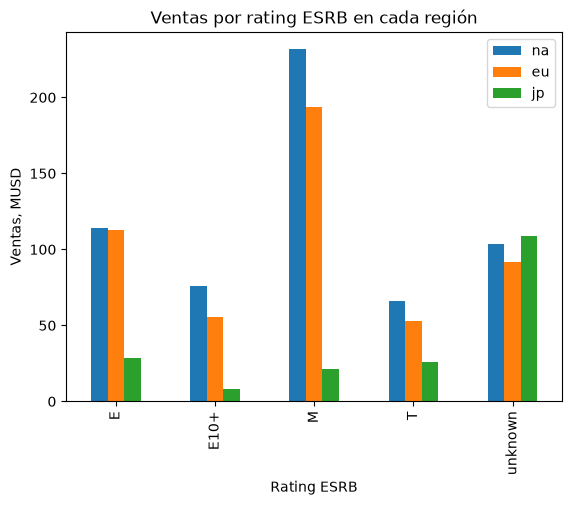

In [66]:
# Gráfico de barras de las ventas por rating ESRB en cada región

esrb_sales.plot(kind='bar', title='Ventas por rating ESRB en cada región', xlabel='Rating ESRB', ylabel='Ventas, MUSD')

plt.show()

Se realiza el análisis de las ventas por clasificaciones ESRB por cada región, nuevamente Norteamérica y Europa muestran un patrón muy similar: los juegos con clasificación M (Mature) concentran la mayor parte de las ventas, seguidos por E (Everyone) y T (Teen), sin contar las que aún no han sido clasificadas. Esto indica que en ambos mercados los títulos dirigidos a un público adulto tienen un peso comercial muy fuerte.

Japón, en cambio, presenta un volumen de ventas mucho menor en todas las categorías, con la excepción de la clasificación “Unknown”, que aparece relativamente alta. Esto sugiere que en el mercado japonés la clasificación ESRB no es un factor tan determinante, probablemente porque allí se utilizan otros sistemas de clasificación.

En conjunto, se observa que las preferencias de Norteamérica y Europa son bastante homogéneas, mientras que Japón se diferencia tanto en volumen como en la distribución de ventas por rating.

### 5. Prueba de hipótesis

### 5.1 Calificaciones promedio de usuarios en plataformas XOne y PC

Hipótesis Nula:

Las calificaciones promedio de los usuarios para las plataformas XOne y PC son las mismas.

Hipótesis Alternativa:

Las calificaciones promedio de los usuarios para las plataformas XOne y PC son diferentes. 

In [67]:

# Calificaciones de usuarios de las plataformas XOne y PC en el periodo relevante por separado

xone_users_score = games[games['platform'] == 'XOne']['user_score'].dropna()
pc_users_score = games[games['platform'] == 'PC']['user_score'].dropna()

print(xone_users_score)
print(pc_users_score)


165      7.9
179      5.4
242      6.4
270      6.2
373      4.1
        ... 
16544    6.8
16597    6.0
16630    8.2
16643    6.6
16660    6.7
Name: user_score, Length: 182, dtype: float64
85       7.6
138      7.3
192      4.0
218      8.2
284      9.1
        ... 
16681    8.1
16692    7.6
16696    5.8
16702    7.2
16705    5.8
Name: user_score, Length: 770, dtype: float64


In [68]:

# Prueba t de Student

alpha = 0.05

test_platforms = st.ttest_ind(xone_users_score, pc_users_score, equal_var = False)

# Imprimir valor p

print('Valor p:', test_platforms.pvalue)

# Resultado conforme el valor p de la comparación del valor p con el nivel de significancia

if (test_platforms.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


Valor p: 4.935072360183566e-06
Rechazamos la hipótesis nula


Se establece la hipótesis nula como la igualdad entre las medias de las calificaciones promedio de las dos plataformas que se desean comparar. Para contrastarla se aplica un test t de Student para dos muestras independientes y de dos colas, el cual permite evaluar si existen diferencias significativas entre las medias de dos grupos.

Se fija el nivel de significancia en 0.05. Este valor se selecciona considerando que se dispone de una cantidad suficiente de datos, lo que brinda robustez al análisis y permite determinar si se rechaza o no la hipótesis nula.

El valor p obtenido es bastante menor que el valor alpha 0.5, por tanto, se rechaza la hipótesis nula, existe evidencia estadísticamente significativa de que los promedios de las calificaciones de las plataformas XOne y PC son diferentes.

En términos del negocio se podría decir que los usuarios aplican criterios diferentes para calificar los juegos en diferentes plataformas. 

### 5.2 Calificaciones promedio de usuarios para los géneros Acción y Deportes

Hipótesis Nula (Ho):

Las calificaciones promedio de los usuarios para los géneros Acción y Deportes son las mismas.

Hipótesis Alternativa (H1):

Las calificaciones promedio de los usuarios para llos géneros Acción y Deportes son diferentes. 

In [69]:
# Calificaciones de usuarios para los géneros Acción y Deportes en el periodo relevante por separado

action_users_score = games[games['genre'] == 'Action']['user_score'].dropna()
sports_users_score = games[games['genre'] == 'Sports']['user_score'].dropna()

print(action_users_score)
print(sports_users_score)

16       8.2
17       9.0
23       8.1
24       8.7
38       8.5
        ... 
16652    8.5
16654    5.1
16660    6.7
16663    2.4
16692    7.6
Name: user_score, Length: 1830, dtype: float64
0        8.0
3        8.0
13       7.7
15       7.4
77       4.3
        ... 
16450    4.5
16518    1.4
16528    6.9
16546    9.5
16643    6.6
Name: user_score, Length: 1103, dtype: float64


In [70]:
# Test t de Student

alpha = 0.05

test_genre = st.ttest_ind(action_users_score, sports_users_score, equal_var=False)

# Imprimir valor p

print('Valor p:', test_genre.pvalue)

# Imprimir resultado de hipótesis

if (test_genre.pvalue < alpha):
    print('Rechazamos la hipótesis nula')
else: 
    print('No podemos rechazar la hipótesis nula')

Valor p: 0.1148381879149829
No podemos rechazar la hipótesis nula


Se compararon las calificaciones promedio de usuarios entre los géneros Action y Sports.

Se estableció el valor alpha en 0.05 ya que se cuenta con suficientes datos para hacer una comparativa robusta.

El resultado de valor p es 0.1148, un valor mayor que el valor alpha esblecido en 0.05, por tanto no podemos rechazar la hipótesis nula, lo que significa que no existe evidencia estadística significativa para decir que los promedios de las calificaciones de usuarios de los géneros de Acción y Deportes son diferentes.

En términos prácticos, esto sugiere que los usuarios califcan de manera similar a los géneros Action y Sports.

## 6. Conclusión general

En primer lugar el análisis realizado a los datos permitió depurar y transformar la base de datos para asegurar su consistencia y confiabilidad. Se estandarizaron los nombres de columnas, se corrigieron tipos de datos y se gestionaron valores ausentes mediante reemplazos adecuados (NaN para datos numéricos y categorías como undefined y unknown para valores faltantes en variables cualitativas). Estas acciones garantizaron la posibilidad de realizar análisis posteriores sin pérdida de información.

En lo que respecta al análisis de datos realizado sobre las plataformas, identificó un grupo reducido con ventas significativamente superiores al resto, destacando PS4, PS3, X360, 3DS y XOne como líderes en el periodo relevante. El mismo que se estableció estudiando el ciclo de vida, el cual mostró que las plataformas alcanzan su máximo de ventas alrededor de los 4 años tras su lanzamiento y mantienen un promedio de 10 años de vigencia en el mercado. En 2017, las plataformas más rentables proyectadas fueron PS4 y XOne, al encontrarse en la fase más reciente de su ciclo de ventas.

El análisis de la distribución de ventas por juego evidenció que la mayoría de los títulos registran ventas bajas (medianas inferiores a 0.3 millones de dólares), aunque existen outliers con ventas extraordinarias que elevan el promedio. Esto refleja un mercado altamente concentrado, donde pocos juegos generan un volumen de ventas desproporcionado frente al resto.

Respecto a la relación entre ventas y reseñas, se concluyó que las calificaciones de usuarios no muestran correlación significativa con las ventas, mientras que las reseñas de críticos presentan una relación positiva moderada (correlaciones cercanas a 0.4). Esto sugiere que la opinión profesional tiene mayor influencia en el desempeño comercial de los juegos que la percepción de los usuarios.

El análisis de géneros y títulos más vendidos mostró que Action, Shooter, Sports y Role-Playing concentran la mayor parte de las ventas, aunque los juegos con mayores ventas individuales pertenecen principalmente al género Shooter (ej. Call of Duty), lo que evidencia que no todos los títulos más exitosos provienen de los géneros más populares.

El estudio realizado por regiones muestra que Norteamérica y Europa comparten patrones muy similares en cuanto a plataformas, géneros y clasificaciones ESRB, mientras que Japón se diferencia tanto en volumen como en preferencias. En plataformas, X360, PS2, Wii y PS3 dominan en Norteamérica y Europa, siendo PS2 la única presente en las tres regiones. En géneros, Action, Shooter, Sports y Role-Playing concentran las ventas en Norteamérica y Europa, mientras que Japón se inclina más hacia Role-Playing y Action, con la particularidad de que Misc también ocupa un lugar relevante.

Las cuotas de mercado refuerzan esta diferencia: Norteamérica concentra el 40% de las ventas, Europa el 35% y Japón apenas el 13%, lo que evidencia un peso comercial mucho mayor Norteamérica y Europa. Además, el análisis de las clasificaciones ESRB confirma que los títulos Mature son los más vendidos en Norteamérica y Europa, mientras que en Japón la categoría “Unknown” tiene un peso mayor, reflejando la menor relevancia del sistema ESRB en este país.

Por tanto, según lo revisado, el plan de campaña para el siguiente año debería priorizar plataformas como PS4 y XOne que aún estan vigentes y tienen ventas altas. Este debería segmentarse por región, pudiendo hacerse una misma campaña para Europa y Norteamérica porque presentan similitudes y una campaña diferente para Japón, considerando también que las primeras regiones son las que tienen mayor cuota de mercado. Se debería potenciar los géneros de Action, Shooter, Sports y Role-Playing, que concentran la mayor parte de las ventas globales y, dado que las reseñas de críticos muestran correlación positiva con las ventas, es recomendable darles importancia al momento de realizar la campaña.

Finalmente, se realizaron dos pruebas de hipótesis, sobre las cuales se resume lo siguiente: 
- En cuanto a las calificaciones de usuarios, se comprobó que existen diferencias significativas entre plataformas como XOne y PC, lo que sugiere que los jugadores aplican criterios diferentes al evaluar juegos en distintos sistemas.
- Al comparar géneros como Action y Sports, el análisis mostró que no hay diferencias significativas en las calificaciones promedio, lo que sugiere que los usuarios califcan de manera similar a los géneros Action y Sports.